In [1]:
# Design an interactive dashboard using plotly to show case 
# a line chart for monthly revenue trends
# a map displaying geographical sales data with markers for each location

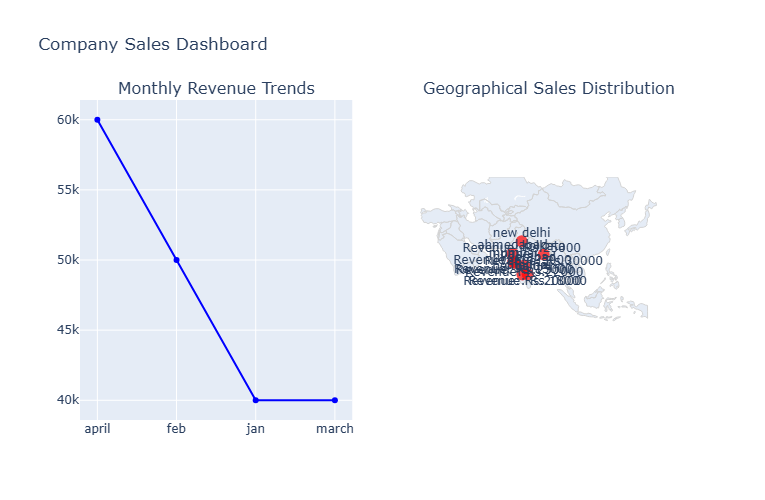

In [60]:
import pandas as pd
import plotly.graph_objects as go # go lets you build individual charts 
from plotly.subplots import make_subplots # make_subplots ,lets you combine multiple charts into one dashboard layout

data = {
    "month":["jan","jan","feb","feb","march","march","april","april"],
    "product category":["electronics","furniture","clothing","electronics","furniture","clothing","electronics","furniture"],
    "revenue":[25000,15000,20000,30000,18000,22000,35000,25000],
    "location":["new delhi","mumbai","bengaluru","kolkata","chennai","hyderabad","ahmedabad","pune"],
    "latitude":[28.613,19.076,12.971,22.572,13.082,17.385,23.022,18.520],
    "longitude":[77.209,72.877,77.594,88.363,80.270,78.486,72.571,73.856]
}

df = pd.DataFrame(data)

# Group by month for line chart
monthly_revenue = df.groupby("month")["revenue"].sum().reset_index() # group entire df by values in month column,only took revenue ignore others

# Create subplot dashboard
fig = make_subplots( # plotly function allows you to create a grid of multiple plots in one fig
    rows=1, cols=2,
    subplot_titles=("Monthly Revenue Trends", "Geographical Sales Distribution"), # title for each subplots,
    column_widths=[0.5, 0.5],
    specs=[[{"type": "scatter"}, {"type": "scattergeo"}]] # tell plotly what type chart goes in each subplot
)

# Line chart (Monthly Revenue)
fig.add_trace(
    go.Scatter(x=monthly_revenue["month"], y=monthly_revenue["revenue"],
               mode="lines+markers", name="Revenue", line=dict(color="blue")), #line=dict(color="blue")) means customise line color to blue 
    row=1, col=1
)

# Geo map with markers
fig.add_trace(
    go.Scattergeo(
        lon=df["longitude"], # longitude coordinates  for location
        lat=df["latitude"],
        text=df["location"] + "<br>Revenue: Rs." + df["revenue"].astype(str), # text shown when hovering over each markerand show both markers and text labels 
        mode="markers+text",
        marker=dict(size=12, color="red", opacity=0.7),
        name="Sales Locations"
    ),
    row=1, col=2
)

# Update geo layout
fig.update_geos( 
    scope="asia", # focus map only on asia
    showcountries=True, # draw country borders
    countrycolor="lightgrey" # set border color to light grey
)

# Layout
fig.update_layout(
    title="Company Sales Dashboard", 
    showlegend=False, # hides legend
    height=500, # height of whole dashboard in pexels
    width=1000
)

fig.show()
